# Phase Mask Design & Fisher Optimisation

In this notebook we will illustrate the inverse design of a phase mask, building from a real-world problem solved using dLux: designing a diffractive pupil phase mask for the Toliman telescope. This work roughly follows the work in both [Wong et al., 2021](https://ui.adsabs.harvard.edu/abs/2021JOSAB..38.2465W/abstract) and [Desdoigts et al., 2025](https://arxiv.org/abs/2406.08704), but is not intended to be a direct reproduction of either. 

This problem provides an interesting design constraint: the phase mask must be binary, with phases of only 0 or π. This serves as an excellent example of how differentiable modelling is able to provide the flexibility to solve problems with complex design constraints quite simply. We will show how we can optimise this mask using two different optimisation metrics, an abstract heuristic metric based on the gradient energy of the psf, as well as a much more statistically rigorous metric based on the Fisher information content of the psf. This tutorial will highlight the flexibility of the dLux framework, as the swapping between these two metrics simply requires changing the loss function, with no changes to the underlying optical model or optimisation procedure.

The tutorial will be divided up into four sections:

1. Building the latent basis
2. Building the optical model
3. Optimising the gradient energy of the PSF
4. Optimising the Fisher information content of the PSF
5. Fisher Analysis of the Masks


In [25]:
# Core jax
import jax
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
from jax import vmap

# Optimisation
import equinox as eqx
import zodiax as zdx
import optax

# Optics
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import CenteredNorm

# Set jax to use 64 bit precision - important for accurate CRLB calculations!
jax.config.update("jax_enable_x64", True)

# Plotting defaults
%matplotlib inline
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams["image.cmap"] = 'inferno'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
binary = mpl.colormaps["binary"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
binary.set_bad("k", 0.5)

---

## 1. Building the latent basis

To construct the binary phase mask we will use the Continuous Latent-Image Mask Binarization (CLIMB) algorithm from the Wong et al. paper. It requires a latent set of continuous basis vectors that are mapped to a binary mask, with a single pixel soft-edged boundary between the 0 and π phase regions to that propagates the gradients safely. Here we will follow the example of the Wong et al. paper and use a set of logarithmic radial harmonics and sines/cosines in $\theta$ as our latent basis, but you can use whatever basis you like here. There is some logic behind this choice, but that is not important for this tutorial. 

Lets see how we can construct this basis and orthonormalise it using PCA. The specifics of this basis construction are not important to understand the rest of the tutorial, so feel free to skip this section if you are not interested in the details.

In [26]:
# Define arrays sizes, samplings, symmetries
wf_npix = 128
oversample = 3
nslice = 3

# Define basis hyper parameters
a = 10
b = 8
ith = 8

# Define coordinate grids
npix = wf_npix * oversample
coords = dlu.pixel_coords(npix, 1.0)
rs = np.hypot(*coords)
phis = np.arctan2(coords[1], coords[0])

# Generate basis vectors to map over
As = np.arange(-a, a + 1)
Bs = nslice * np.arange(0, b + 1)
Cs = np.array([-np.pi / 2, np.pi / 2])
Is = np.arange(-ith, ith + 1)

# Define basis functions
LRHF_fn = lambda A, B, C: np.cos(A * np.log(rs + 1e-12) + B * phis + C)
sine_fn = lambda i: np.sin(i * np.pi * rs)
cose_fn = lambda i: np.cos(i * np.pi * rs)

# Map over basis function
gen_LRHF_basis = vmap(
    vmap(vmap(LRHF_fn, (None, 0, None)), (0, None, None)), (None, None, 0)
)

# Generate basis
full_LRHF_basis = gen_LRHF_basis(As, Bs, Cs)
sine_basis = vmap(sine_fn)(Is)
cose_basis = vmap(cose_fn)(Is)

# Format shapes and combine
LRHF_flat = full_LRHF_basis.reshape([len(As) * len(Bs) * len(Cs), npix * npix])
sine_flat = sine_basis.reshape([len(sine_basis), npix * npix])
cose_flat = cose_basis.reshape([len(cose_basis), npix * npix])
full_basis = np.concatenate([LRHF_flat, sine_flat, cose_flat])

Orthonormalise with PCA -- you could also use Gram-Schmidt if you prefer. Note this PCA can take a minute or two to run.

In [27]:
from sklearn.decomposition import PCA

pca = PCA().fit(full_basis)
basis = pca.components_.reshape([-1, npix, npix])[:99]
basis = np.concatenate([np.mean(pca.mean_) * np.ones_like(basis[:1]), basis])

Visualising the pretty basis vectors:

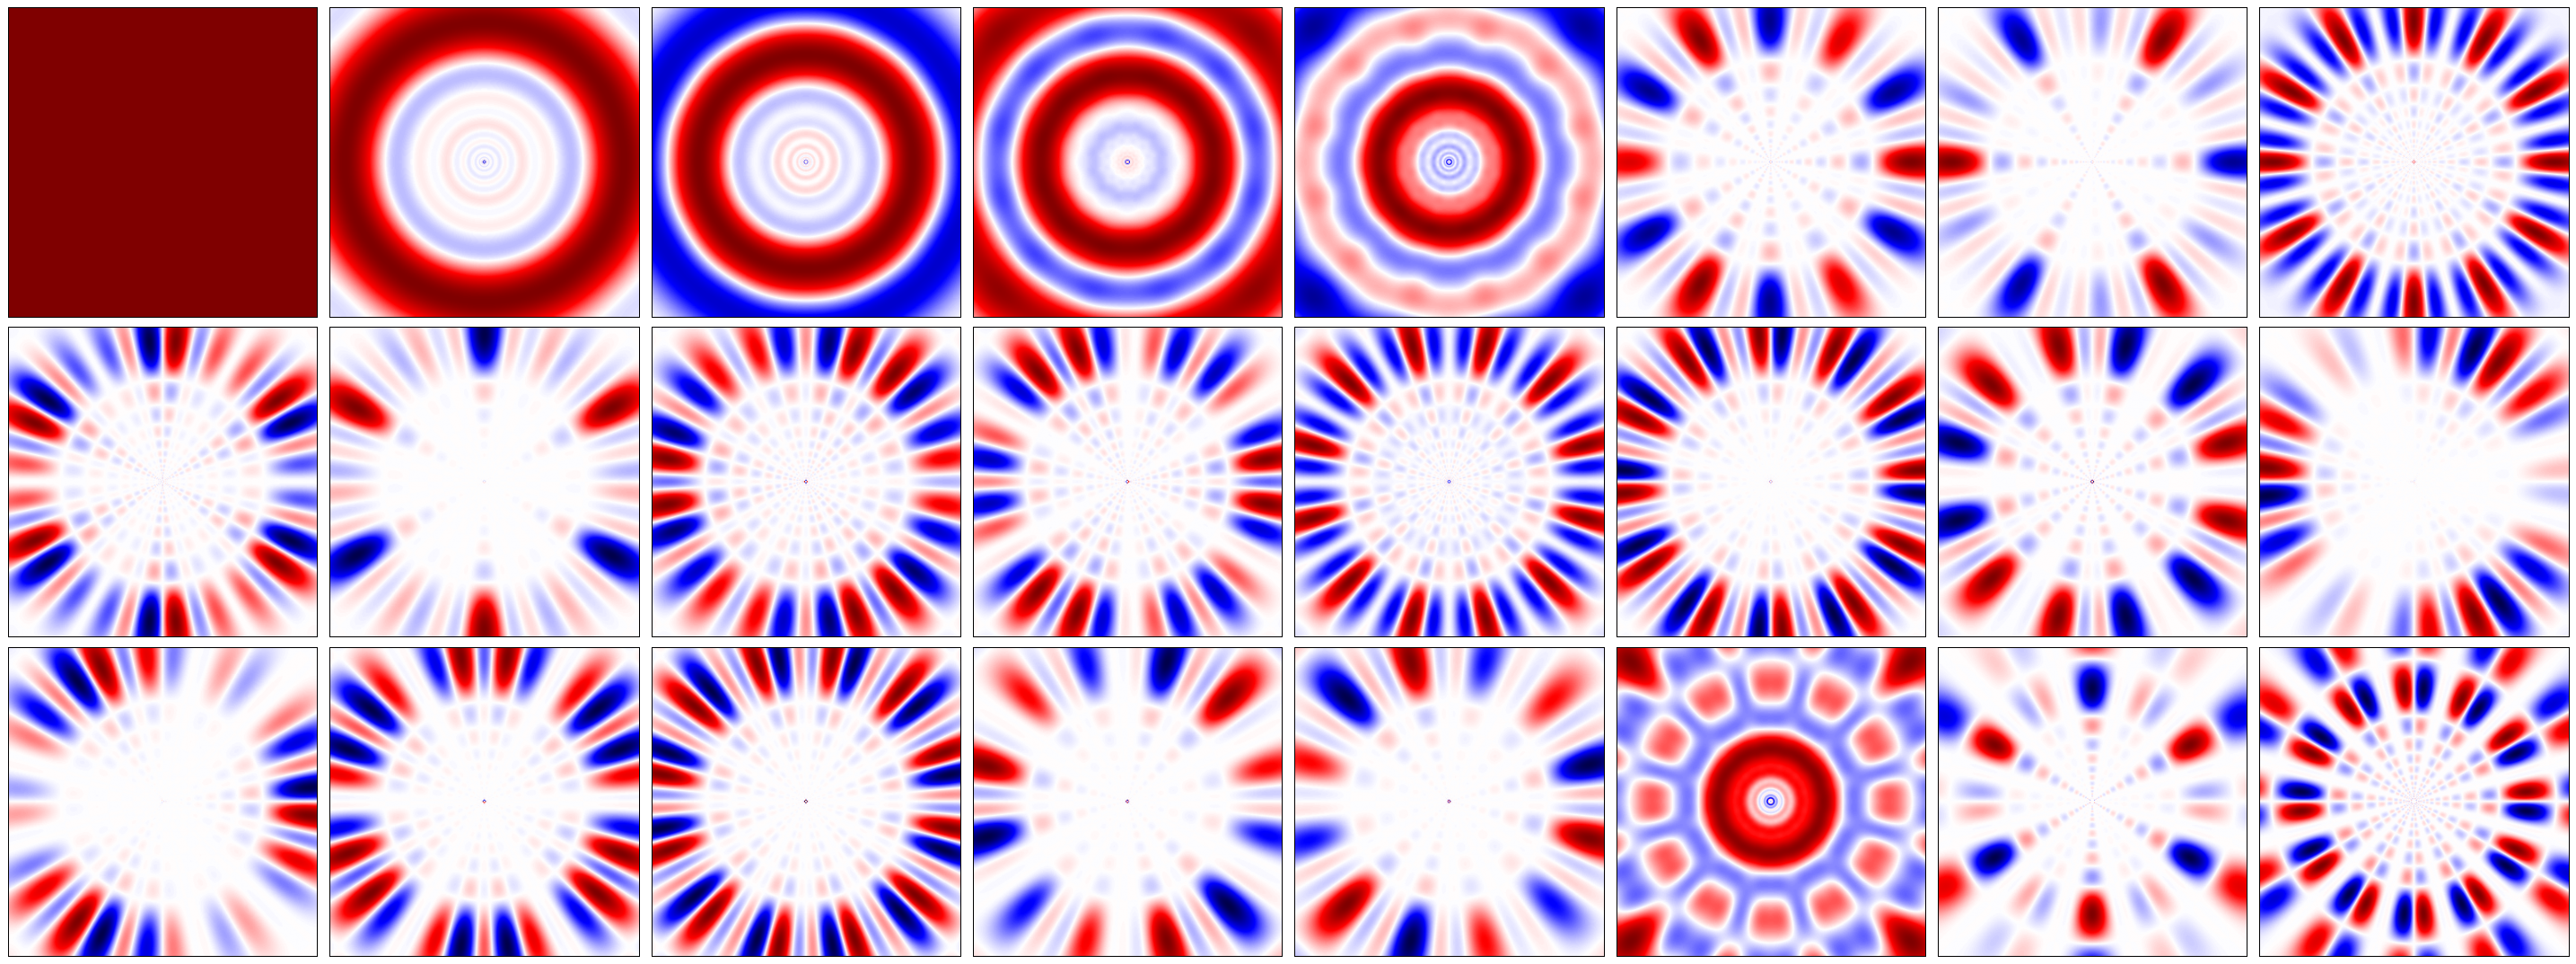

In [28]:
nfigs = 24
ncols = 8
nrows = 1 + nfigs // ncols

plt.figure(figsize=(4 * ncols, 4 * nrows))
for i in range(nfigs):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(basis[i], "seismic", norm=CenteredNorm())
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

---

## 2. Building the Optical Model

This section will cover how we can construct an optical model that uses the CLIMB algorithm to map from the latent basis to a binary phase mask. To do this, we need to create a custom dLux layer that calls the dLux implementation of the CLIMB algorithm. This serves as a good example of how we can easily extend the dLux framework with custom layers that can be used in the same way as any other dLux layer, and can be seamlessly integrated into the rest of the optical model and optimisation procedure, leveraging the structure of existing classes to simplify our code. We will build our optical model to match the Toliman space telescope.


In [29]:
# Build the CLIMB basis layer
class BasisCLIMB(dl.BasisLayer):
    """Maps a set of latent basis vectors to a binary phase mask using the CLIMB
    algorithm implements via the dLux `soft_binarise` function. We extend the
    `BasisLayer` class in dLux, which stores the basis and coefficients. We only need
    to implement the `__call__` method to apply the basis as an OPD to the wavefront,
    define a function to generate the binary mask from the basis using the CLIMB
    algorithm, and define a target wavelength that the OPD mask will produce a perfect
    0-π anti-phase."""
    wavelength: np.ndarray

    def __init__(self, basis, wl, coeffs=None):
        self.wavelength = wl
        super().__init__(basis, coeffs)

    @property
    def binary_mask(self):
        return 2 * dlu.soft_binarise(self.eval_basis(), 3) - 1

    def __call__(self, wavefront):
        # Apply the basis as an OPD to the wavefront
        phase_basis = np.pi * self.binary_mask / 2
        return wavefront.add_opd(dlu.phase2opd(phase_basis, self.wavelength))

Build the optical system


In [30]:
# Observational wavelengths
wavels = 1e-9 * np.linspace(595, 695, 5)

# build the CLIMB mask layer
coeffs = 100 * jr.normal(jr.PRNGKey(1), (basis.shape[0],))

# Build our Toliman aperture and zernike aberrations
diameter = 0.125
z_nolls = np.arange(4, 16)
z_names = [dlu.zernike_name(i) for i in z_nolls]
aperture, z_basis, z_support = dlu.circular_aperture(
    npixels=wf_npix,
    diameter=diameter,
    oversample=5,
    secondary_diameter=0.032,
    spider_width=0.002,
    spider_angles=[0, 120, 240],
    zernike_nolls=z_nolls,
    return_support=True,
)

# Normalise the zernikes to 1nm rms and build the aperture layer
z_basis /= 1e9 * dlu.rms_norm(z_basis, z_support, axis=(1, 2), keepdims=True)

# Build the optics
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix,
    diameter=diameter,
    layers=[
        ("aperture", dl.BasisOptic(transmission=aperture, basis=z_basis, normalise=True)),
        ("pupil", BasisCLIMB(basis, wl=wavels.mean(), coeffs=coeffs)),
    ],
    psf_npixels=80,
    psf_pixel_scale=0.25,
)

Now lets have a look at our optical model and PSF

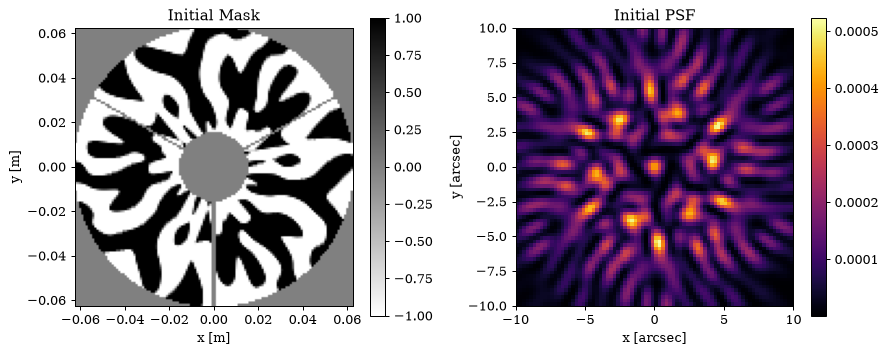

In [31]:
# Get the initial PSF and mask
aperture = optics.aperture.transmission
nan_aper = lambda x: x.at[~(aperture > 0.0)].set(np.nan)
initial_mask = nan_aper(optics.pupil.binary_mask)
initial_psf = optics.propagate(wavels)

# Image extents
aper_ext = dlu.imshow_extent(optics.diameter)
psf_ext = dlu.imshow_extent(optics.fov)

# Plot
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 2, 1)
im = ax.imshow(initial_mask, binary, extent=aper_ext, norm=CenteredNorm())
plt.colorbar(im, ax=ax)
ax.set(title="Initial Mask", xlabel="x [m]", ylabel="y [m]")

ax = plt.subplot(1, 2, 2)
im = ax.imshow(initial_psf, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Initial PSF", xlabel="x [arcsec]", ylabel="y [arcsec]")
plt.tight_layout()
plt.show()

---

## 3. Optimising the Gradient Energy of the PSF

In this section we will look at how we can optimise the phase mask to minimise an abstract heuristic metric based on the gradient energy of the PSF. This is not a rigorous metric, but more akin to a PSF heuristic that we see in coronagraphy, such as the weighting between on-axis supression and off-axis throughput. Here we want to use the gradient energy of the PSF as a rough metric for how well we can constrain the position of the PSF, while ensuring that the flux is spread into a number of different lobes that spans the on-sky separation of the Alpha Centauri binary. We will use a mask that only considers the gradient energy within a certain radius to concentrate the light into a small number of lobes. In this case we will use 8 fringes, i.e. 8 λ/D, which is approximately the separation of the Alpha Centauri binary.

First we build the gradient energy functions and our loss metric


In [32]:
def GE_fn(array):
    """Calculate the gradient energy of an array."""
    return np.hypot(*np.gradient(array))

def RGE_fn(array):
    """Calculate the radial gradient energy of an array."""
    npix = array.shape[0]
    positions = dlu.pixel_coords(npix, npix)
    grads_vec = np.array(np.gradient(array))[::-1]
    return np.sum(positions * grads_vec, axis=0) ** 2

# Build the radial mask
true_npixels = optics.psf_npixels * optics.oversample
radii = dlu.pixel_coords(true_npixels, optics.fov, polar=True)[0]
rmax = 8 * dlu.rad2arcsec(wavels.max() / diameter)
radial_mask = radii < rmax

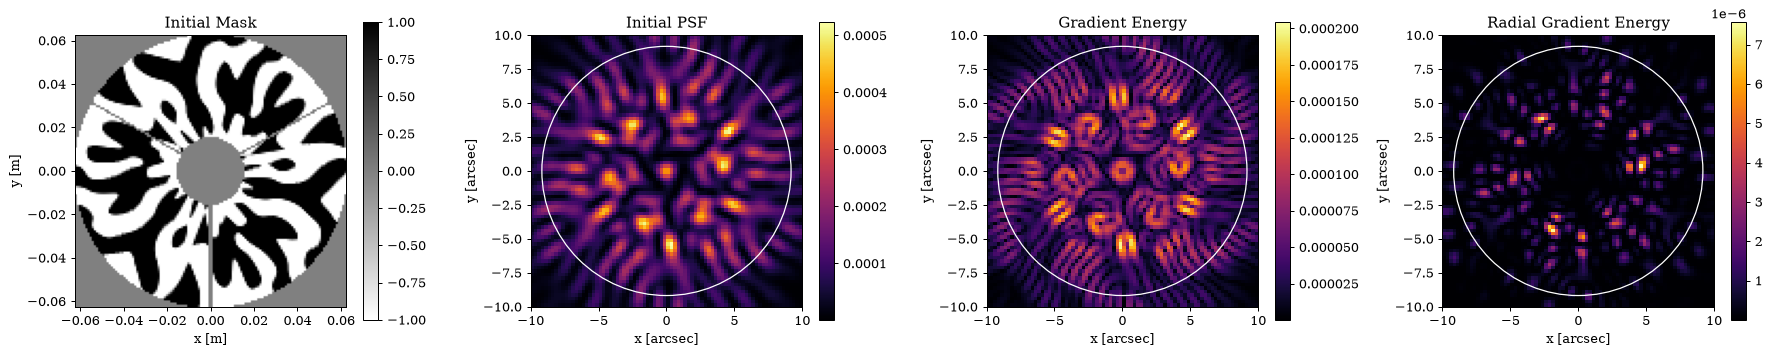

In [33]:
# Plot
plt.figure(figsize=(20, 4))
ax = plt.subplot(1, 4, 1)
im = ax.imshow(initial_mask, binary, extent=aper_ext, norm=CenteredNorm())
plt.colorbar(im, ax=ax)
ax.set(title="Initial Mask", xlabel="x [m]", ylabel="y [m]")

ax = plt.subplot(1, 4, 2)
im = ax.imshow(initial_psf, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Initial PSF", xlabel="x [arcsec]", ylabel="y [arcsec]")
ax.add_patch(plt.Circle((0, 0), rmax, fill=False, color="w"))

ax = plt.subplot(1, 4, 3)
im = ax.imshow(GE_fn(initial_psf), extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Gradient Energy", xlabel="x [arcsec]", ylabel="y [arcsec]")
ax.add_patch(plt.Circle((0, 0), rmax, fill=False, color="w"))

ax = plt.subplot(1, 4, 4)
im = ax.imshow(RGE_fn(initial_psf), extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Radial Gradient Energy", xlabel="x [arcsec]", ylabel="y [arcsec]")
ax.add_patch(plt.Circle((0, 0), rmax, fill=False, color="w"))
plt.tight_layout()
plt.show()

Now, let's define our loss function and run a simple gradient descent loop to optimize our mask!


In [34]:
@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, optics, radial_mask, power=0.45):
    psf = optics.set(params).propagate(wavels)
    loss1 = -1 * np.power(radial_mask * GE_fn(psf), power).sum()
    loss2 = -1 * np.power(radial_mask * RGE_fn(psf), power).sum()
    return loss1 + loss2

# Set up the parameters and optimiser
params = optics.get("pupil.coefficients", as_dict=True)
optimisers = {"pupil.coefficients": optax.adam(2e1)}
optim, opt_state = zdx.map_optimisers(params, optimisers)

# Run the optimisation loop
losses, params_out = [], []
with tqdm(range(300),desc='Gradient Descent') as t:
    for i in t: 
        loss, grads = loss_fn(params, optics, radial_mask)
        updates, opt_state = optim.update(grads, opt_state)
        params = eqx.apply_updates(params, updates)
        params_out.append(params)
        losses.append(loss)
        t.set_description("Loss: {:.3f}".format(loss)) # update the progress bar

Gradient Descent:   0%|          | 0/300 [00:00<?, ?it/s]

Visualising the results:

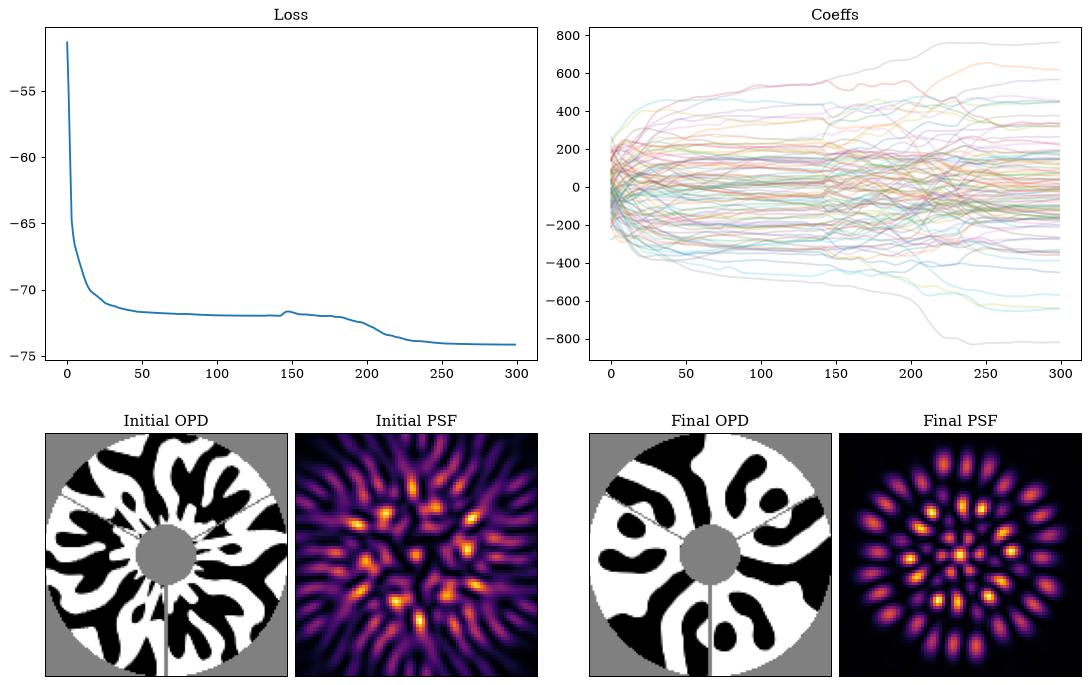

In [35]:
coeffs_out = np.array([p["pupil.coefficients"] for p in params_out])
final_mask = nan_aper(optics.set(params).pupil.binary_mask)
final_psf = optics.set(params).propagate(wavels)
final_ge_coeffs = coeffs_out[-1]

mosaic = """
            AABB
            CDEF
            """

fig = plt.figure(constrained_layout=True, figsize=(12, 8))
axes = fig.subplot_mosaic(mosaic)

for ax in ["C", "D", "E", "F"]:
    axes[ax].set_xticks([])
    axes[ax].set_yticks([])

axes["A"].plot(np.array(losses))
axes["A"].set_title("Loss")

axes["B"].set_title("Coeffs")
axes["B"].plot(coeffs_out[:], alpha=0.2)

axes["C"].imshow(initial_mask, cmap=binary)
axes["C"].set_title("Initial OPD")

axes["D"].imshow(initial_psf)
axes["D"].set_title("Initial PSF")

axes["E"].imshow(final_mask, cmap=binary)
axes["E"].set_title("Final OPD")

axes["F"].imshow(final_psf)
axes["F"].set_title("Final PSF")
plt.show()

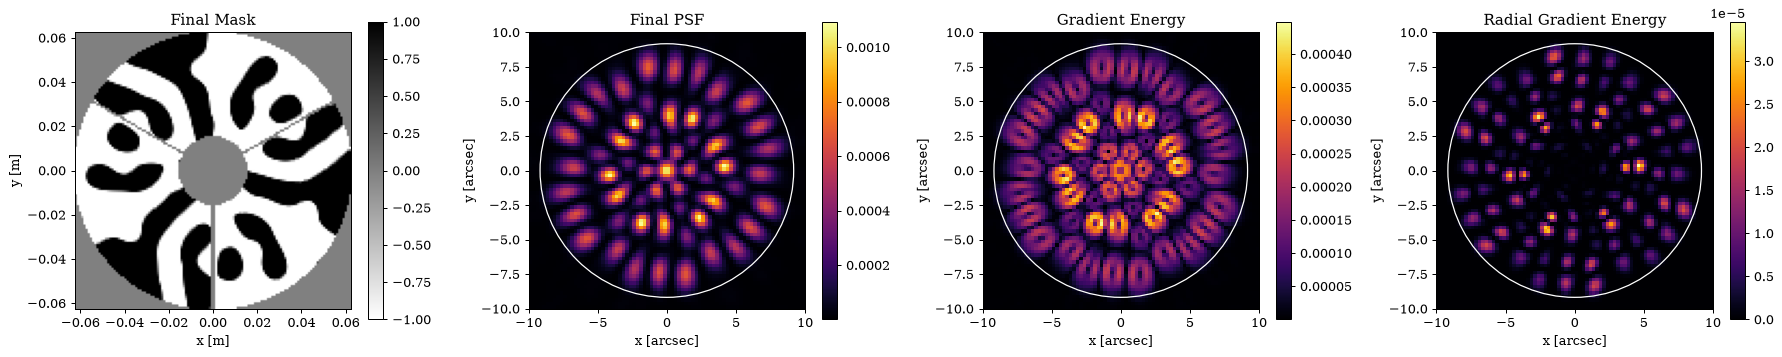

In [36]:
plt.figure(figsize=(20, 4))
ax = plt.subplot(1, 4, 1)
im = ax.imshow(final_mask, binary, extent=aper_ext, norm=CenteredNorm())
plt.colorbar(im, ax=ax)
ax.set(title="Final Mask", xlabel="x [m]", ylabel="y [m]")

ax = plt.subplot(1, 4, 2)
im = ax.imshow(final_psf, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Final PSF", xlabel="x [arcsec]", ylabel="y [arcsec]")
ax.add_patch(plt.Circle((0, 0), rmax, fill=False, color="w"))

ax = plt.subplot(1, 4, 3)
im = ax.imshow(GE_fn(final_psf), extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Gradient Energy", xlabel="x [arcsec]", ylabel="y [arcsec]")
ax.add_patch(plt.Circle((0, 0), rmax, fill=False, color="w"))

ax = plt.subplot(1, 4, 4)
im = ax.imshow(RGE_fn(final_psf), extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Radial Gradient Energy", xlabel="x [arcsec]", ylabel="y [arcsec]")
ax.add_patch(plt.Circle((0, 0), rmax, fill=False, color="w"))
plt.tight_layout()
plt.show()

Cool! As we can see we now a super-cool looking mask and PSF with all the light concentrated into the radius we wanted, spread approximately evenly into many lobes. Now lets turn to a more rigorous metric based on the Fisher information content of the PSF.

---

## 4. Optimising the Fisher Information Content of the PSF

Another great benefit to differentiable modelling is that we gain access to efficient high-order derivatives, such as Jacobians and Hessians. This allows us to use much more rigorous metrics for our optimisation, such as the Fisher information content of the PSF. The Fisher information content is a measure of how much information about a parameter is contained within an observation. Here we will extend the previous phase mask design to the work demonstrated in the [Desdoigts et al., 2025](https://arxiv.org/abs/2406.08704) paper, optimising the phase mask to maximise the Fisher information content of the PSF with respect to the separation of the Alpha Centauri binary. This is a much more rigorous metric than the gradient energy, as it directly measures how well we can constrain the separation of the binary given the PSF, rather than relying on a heuristic metric that may not be directly related to our scientific goal. If you want more information on this process, it can be found in the paper. 

It is quite simple to extend our code to do this, as we mostly need to set up the modelling of a binary star, and write a new loss function that calculate the Fisher information matrix of the PSF with respect to all of our parameter of interest - ie, those used to model the binary star as well as any other parameters we need to calibrate through the process..


In [37]:
# Define a simple Modelling function for a binary star PSF
def model_fn(params, optics):
    """Models a binary star PSF"""
    # Cast from nice units to calculation units
    sep_rad = dlu.arcsec2rad(params["separation"])
    pos_angle = np.deg2rad(params["pos_angle"])
    flux = 10 ** params["flux"]
    d_wavel = 1e-9 * params["wavel"]

    # Get the true positions and fluxes
    positions = dlu.positions_from_sep(np.zeros(2), sep_rad, pos_angle)
    fluxes = dlu.fluxes_from_contrast(flux, params["contrast"])

    # Update the optics with the relevant parameters
    optics = optics.set(
        ["aperture.coefficients", "psf_pixel_scale"],
        [params["aberrations"], params["pix_scale"]],
    )

    # Propagate the PSF for each source position
    psfs = vmap(lambda pos: optics.propagate(wavels + d_wavel, pos))(positions)

    # Combine the PSFs with the fluxes to get the final image
    return np.sum(fluxes[:, None, None] * psfs, axis=0)


# Define the function to calculate our Fisher information matrix
def fisher_fn(params, optics, n_frames=1, read_noise=1.):
    """Calculate the Fisher Information Matrix"""
    # Generate the PSF and error for the number of frames
    psf = model_fn(params, optics)
    error = np.sqrt((psf + read_noise**2) / n_frames)

    # Calculate the Fisher information matrix
    fn = lambda params: -zdx.loglike(model_fn(params, optics), psf, error).sum()
    return zdx.hessian(fn, params, checkpoint=False)

Now lets set up the fiducial binary star and optical parameters for our model. We need to set up our 'marginal parameters' - these are the parameters that we calculate our Fisher matrix with respect to, and that we want to constrain with our data. Note that what answer we get is quite sensitive to the choice of these parameters, as they determine what information we are trying to maximise in our PSF. In the Toliman case, its important that we also constrain the mean wavelength and the pixel scale as these are very covariant with our parameter of interest, the separation of the binary, which is why we marginalise over them in our Fisher matrix calculation.

We also set up our optical system to model a wider field of view to capture the extent of both of the PSFs from the binary star. Lets have a look at how to do that, and look at our cramer-rao lower bounds (CRLBs) for our initial model


In [38]:
# Define our marginal parameters for the binary star model
marginal_params = {
    "separation": 10.0,  # arcsec
    "pos_angle": 90.0,  # degrees
    "contrast": 3.37,  # contrast ratio
    "flux": 6.6,  # Approx photons per frame
    "pix_scale": 0.3,  # arcsec per pixel
    "wavel": 0.,  # Mean observational wavelength (nm)
    "aberrations": np.zeros(z_basis.shape[0]),  # initial aberration coefficients
}

# Tweak our modelling parameters to capture the binary
optics = optics.set(
    {
        "oversample": 1,
        "psf_npixels": 100,
        "pupil.coefficients": coeffs,
    }
)

# Look at the initial PSF
psf = model_fn(marginal_params, optics)

# Get the Cramer-Rao lower bound on the separation for the initial mask
F, unravel_fn = fisher_fn(marginal_params, optics)
cramer_rao = unravel_fn(np.diag(np.linalg.inv(F)) ** 0.5)

# Examine the Cramer-Rao lower bounds for our parameters
cramer_rao

{'aberrations': Array([0.05805599, 0.04887112, 0.04871711, 0.05079181, 0.05070691,
        0.05192154, 0.05274292, 0.05729396, 0.04902848, 0.04993539,
        0.04686488, 0.04761972], dtype=float64),
 'contrast': Array(0.00528265, dtype=float64),
 'flux': Array(0.00017986, dtype=float64),
 'pix_scale': Array(7.86336441e-05, dtype=float64),
 'pos_angle': Array(0.00352376, dtype=float64),
 'separation': Array(0.0026993, dtype=float64),
 'wavel': Array(0.16466757, dtype=float64)}

Lets have a quick look at our initial mask and what our binary star looks like through our initial optical system

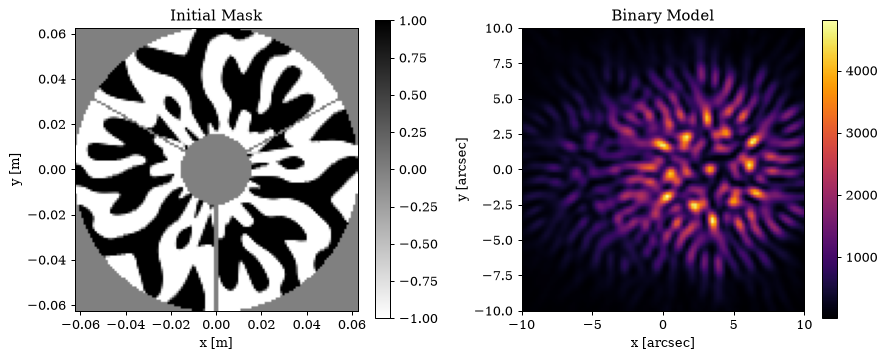

In [39]:
 # Get the initial PSF and mask
start_mask = nan_aper(optics.pupil.binary_mask)

# Plot
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 2, 1)
im = ax.imshow(start_mask, binary, extent=aper_ext, norm=CenteredNorm())
plt.colorbar(im, ax=ax)
ax.set(title="Initial Mask", xlabel="x [m]", ylabel="y [m]")

ax = plt.subplot(1, 2, 2)
im = ax.imshow(psf, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Binary Model", xlabel="x [arcsec]", ylabel="y [arcsec]")
plt.tight_layout()
plt.show()

Now can define our loss function very easily, calculating the Fisher information matrix and then extracting out the Cramer-Rao lower bound on the separation of the binary. The benefit of this approach is this this lower-bound is _marginalised_ over our other parameters of interest, so we are directly optimising the information content of our PSF with respect to the separation of the binary, while accounting for the covariances with our other parameters of interest.

We can then also run a simple gradient descent loop in the exact same way as before to optimise our mask, just with a different loss function! Note that this computation can be quite expensive, especially in 64-bit precision, so it can take a some time to run depending on your hardware.


In [40]:
# Define our loss function as the Cramer-Rao lower bound on the binary separation
@eqx.filter_jit
@eqx.filter_value_and_grad
def fisher_loss_fn(mask_params, model_params, optics, n_frames=1, read_noise=2.5):
    """Calculates the loss as the Cramer-Rao lower bound on the binary separation"""
    # Update the optics with the new mask parameters
    optics = optics.set(mask_params)

    # Calculate the fisher matrix
    F, unravel_fn = fisher_fn(model_params, optics, n_frames, read_noise)

    # Invert it to get the Cramer-Rao lower bound on the parameter standard deviation
    return unravel_fn(np.diag(np.linalg.inv(F)) ** 0.5)["separation"]


# Set up the parameters and optimiser
params = {"pupil.coefficients": coeffs}
optimisers = {"pupil.coefficients": optax.adam(2e2)}
optim, opt_state = zdx.map_optimisers(params, optimisers)

# Run the optimisation loop
looper = tqdm(range(250))
losses, params_out = [], [params]
for i in looper:
    loss, grads = fisher_loss_fn(params, marginal_params, optics)
    updates, opt_state = optim.update(grads, opt_state)
    params = eqx.apply_updates(params, updates)
    params_out.append(params)
    losses.append(loss)
    looper.set_description("Loss (mas): {:.3f}".format(1e3 * loss))

  0%|          | 0/250 [00:00<?, ?it/s]

KeyboardInterrupt: 

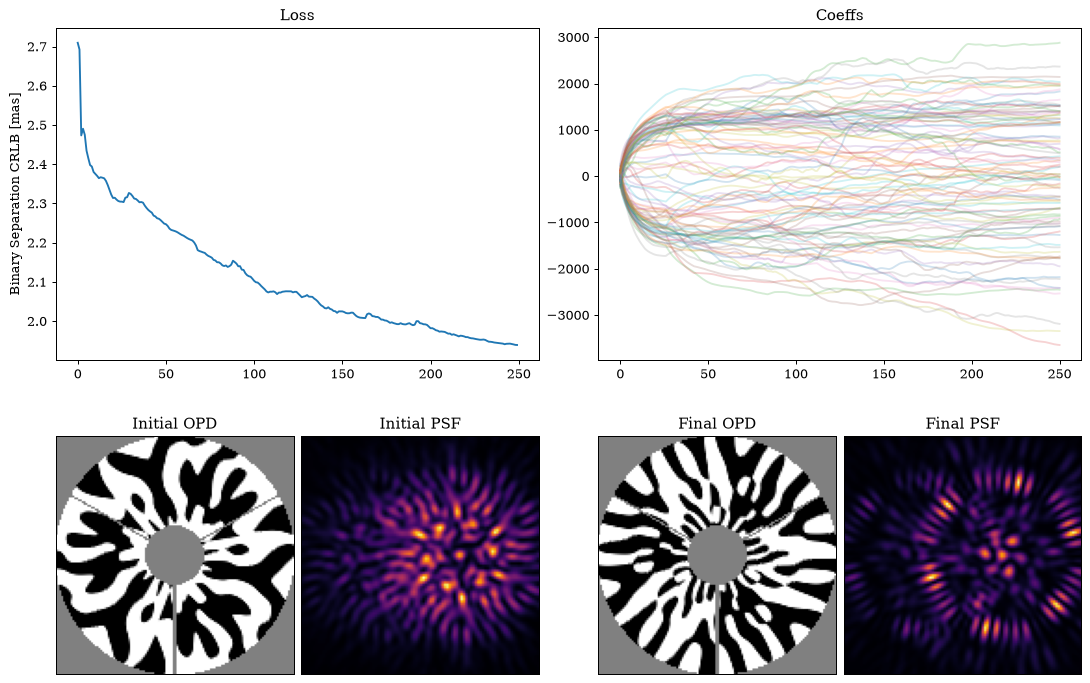

In [ ]:
# Get the initial and final masks and PSFs
initial_mask = nan_aper(optics.set(params_out[0]).binary_mask)
final_mask = nan_aper(optics.set(params_out[-1]).binary_mask)

# Get the initial and final PSFs for the binary model
initial_psf = model_fn(marginal_params, optics.set(params_out[0]))
final_psf = model_fn(marginal_params, optics.set(params_out[-1]))

# Get the final fisher optimized coefficients
final_fisher_coeffs = params_out[-1]["pupil.coefficients"]

mosaic = """
        AABB
        CDEF
        """

fig = plt.figure(constrained_layout=True, figsize=(12, 8))
axes = fig.subplot_mosaic(mosaic)

for ax in ["C", "D", "E", "F"]:
    axes[ax].set_xticks([])
    axes[ax].set_yticks([])

axes["A"].plot(1e3 * np.array(losses))
axes["A"].set_title("Loss")
axes["A"].set_ylabel("Binary Separation CRLB [mas]")

axes["B"].set_title("Coeffs")
axes["B"].plot(np.array([p["pupil.coefficients"] for p in params_out]), alpha=0.2)

axes["C"].imshow(initial_mask, cmap=binary)
axes["C"].set_title("Initial OPD")

axes["D"].imshow(initial_psf)
axes["D"].set_title("Initial PSF")

axes["E"].imshow(final_mask, cmap=binary)
axes["E"].set_title("Final OPD")

axes["F"].imshow(final_psf)
axes["F"].set_title("Final PSF")
plt.show()

---

## 5. Fisher Analysis of the Masks

Okay awesome, now that we have all of this set up, we can use the Fisher calculation code to do some rigorous statistical analysis of our masks. Here we we will compare the CRLB values for the initial random mask, the gradient energy optimised mask, the Fisher optimised mask, and the Airy disk (i.e. no mask) to see how much of an improvement we get from our optimised masks, and how much better the Fisher optimised mask is compared to the gradient energy optimised mask. We can also calculate the relative efficiency of each mask compared to the Fisher optimised mask to get a sense of how much of an improvement we get from our optimisation.

Lets start by looking at the marginalised posteriors of all of our parameters of interest for each mask. We wont examine the covariances here, as that plots get our of hand quickly, but we can see how well each mask constrains our parameters easily!


In [ ]:
# Cramer-Rao Lower Bound (CRLB) convenience function
def calc_crlb(optics, n_frames=1, read_noise=2.5):
    F, unravel_fn = fisher_fn(marginal_params, optics, n_frames, read_noise)
    return unravel_fn(np.diag(np.linalg.inv(F)) ** 0.5)

# Set up the optical systems with each mask
airy_optics = optics.set("pupil.coefficients", np.zeros_like(coeffs))
rand_optics = optics.set("pupil.coefficients", coeffs)
ge_optics = optics.set("pupil.coefficients", final_ge_coeffs)
fisher_optics = optics.set("pupil.coefficients", final_fisher_coeffs)

# Calculate the CRLB for each mask
crlbs = {
    "Airy": calc_crlb(airy_optics),
    "Random": calc_crlb(rand_optics),
    "GE Optimised": calc_crlb(ge_optics),
    "Fisher Optimised": calc_crlb(fisher_optics),
}

Quick-look at the separation constraints, as we can see, we are doing _much_ better than the Airy disk - even with our randomly initialised mask! This is a consequence of choosing a good latent basis that is restricted to symmetries that are relevant to our problem, which is a great example of how we can use our domain knowledge to guide the design of our latent space to make the optimisation easier. 


In [ ]:
for label, crlb in crlbs.items():
    print(f"{label} Separation CRLB: {1e3 * crlb['separation']:.3f} mas")

Airy Separation CRLB: 16.358 mas
Random Separation CRLB: 2.710 mas
GE Optimised Separation CRLB: 2.690 mas
Fisher Optimised Separation CRLB: 1.941 mas


Lets examine our main parameters (i.e. not the aberrations)

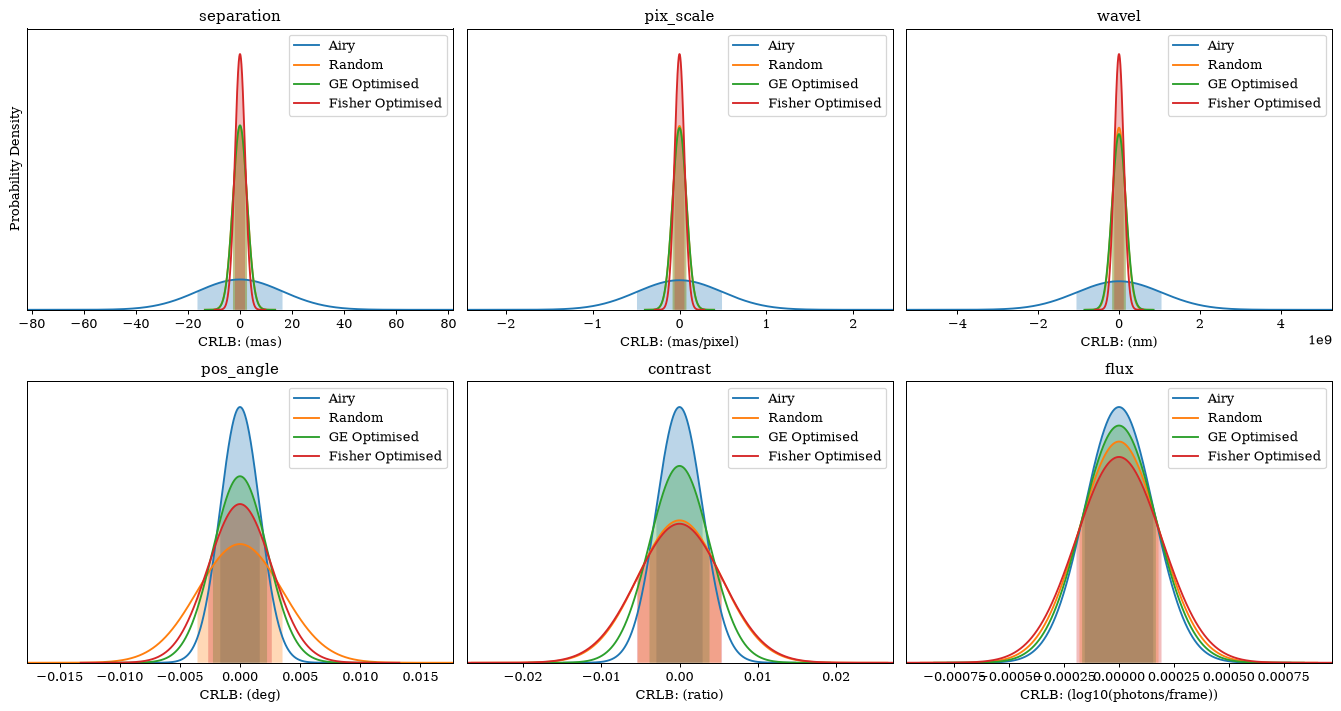

In [ ]:
# Simple plotting convenience function
def plot_std(ax, std, param="", unit="", label="", meta={}):
    # Get the normalised PDF of the error distribution
    xs = np.linspace(-5 * std, 5 * std, 2000)
    ys = jsp.stats.norm.pdf(xs, scale=std)

    # Deal with the plot meta-data
    meta = {"xmax": 0.0, "ymax": 0.0} if len(meta) == 0 else meta
    meta["xmax"] = std if std > meta["xmax"] else meta["xmax"]
    meta["ymax"] = ys.max() if ys.max() > meta["ymax"] else meta["ymax"]
    xlim, ylim = (-5 * meta["xmax"], 5 * meta["xmax"]), (0, meta["ymax"] * 1.1)

    # Plot the bits
    ax.plot(xs, ys, label=label)
    mask = (xs >= -std) & (xs <= std)
    ax.fill_between(xs[mask], ys[mask], alpha=0.3)
    ax.set(title=param, xlabel=f"CRLB: ({unit})", xlim=xlim, ylim=ylim, yticks=[])
    return ax, meta

# Plotting config
plot_cfg = {
    "separation": {"unit": "mas", "scale": 1e3},
    "pix_scale": {"unit": "mas/pixel", "scale": 1e3},
    "wavel": {"unit": "nm", "scale": 1e9},
    "pos_angle": {"unit": "deg", "scale": 1.0},
    "contrast": {"unit": "ratio", "scale": 1.0},
    "flux": {"unit": "log10(photons/frame)", "scale": 1.0},
}

# Plot
plt.figure(figsize=(15, 8))
for i, (param, cfg) in enumerate(plot_cfg.items()):
    ax = plt.subplot(2, 3, i + 1)

    meta = {}
    for label, cramer_rao in crlbs.items():
        std = cfg["scale"] * cramer_rao[param]
        ax, meta = plot_std(ax, std, param, cfg["unit"], label, meta=meta)
    if i == 0:
        ax.set_ylabel("Probability Density")
    ax.legend()
plt.tight_layout()
plt.show()

Interesting! As we can see even though we do much better than the Airy disk on our separation (and a few other parameters), we do worse a few others. This is a consequence of the fact that we are optimising the mask to maximise the information content with respect to the separation - ultimately there is only so much information we can encode into the PSF, so we have to make trade-offs between what parameters we want to constrain well and which ones we are happy to be more uncertain about. This is where the power of this design method shines, since it is aware of how these parameters all affect one another, it can trade-off information about less important parameters to maximise the information about our parameter of interest, which is exactly what we want to do in this case.

Now lets also take a look at our aberrations constraints.

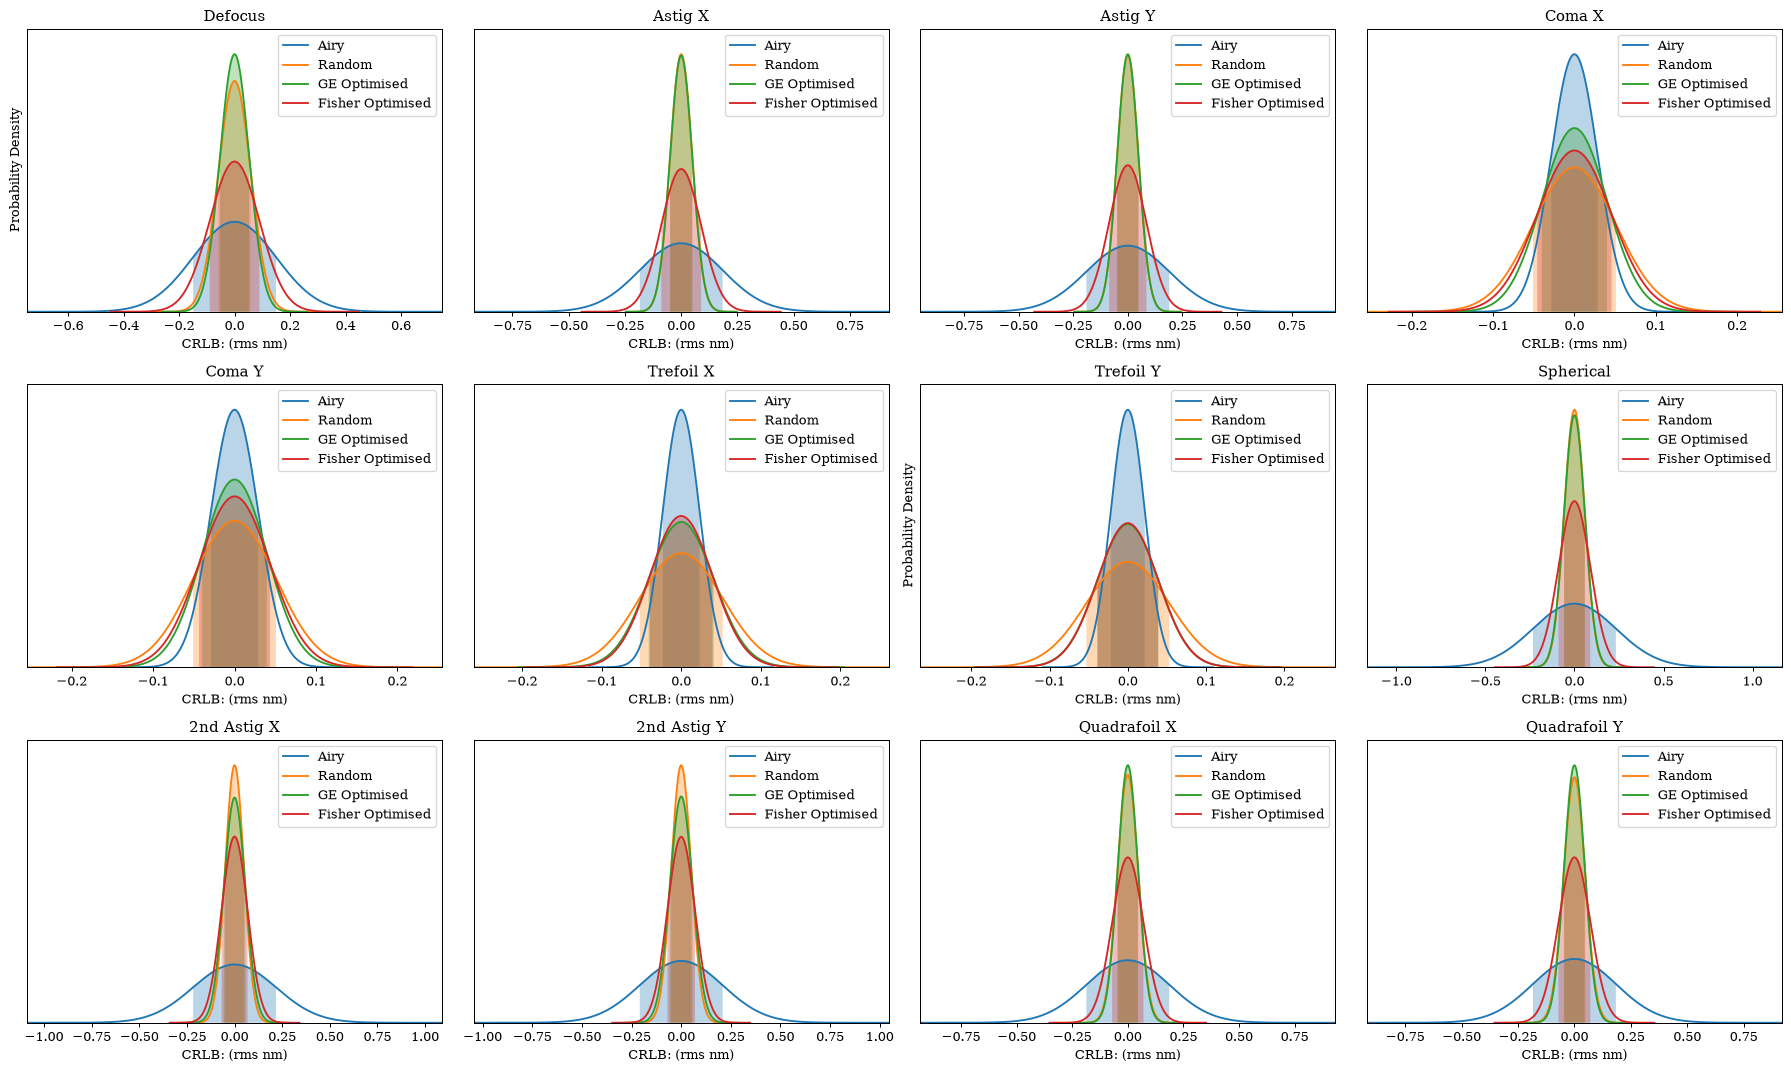

In [ ]:
plt.figure(figsize=(20, 12))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    
    meta = {}
    for label, cramer_rao in crlbs.items():
        std = cramer_rao["aberrations"]
        ax, meta = plot_std(ax, std[i], z_names[i], unit="rms nm", label=label, meta=meta)
    if i in [0, 6]:
        ax.set_ylabel("Probability Density")
    ax.legend()


plt.tight_layout()
plt.show()

Okay cool, we can see the same sort of thing going on here, each mask constrains some aberrations better than others, but the Fisher optimised mask is able to find a good balance that allows it to constrain the separation of the binary much better than the other masks, while still constraining the aberrations reasonably well.

Finally, lets have a look at some other interesting analysis. Lets answer the question 'how long do we need to observe for with each mask to achieve the desired separation constraint? (1 micro-arcsecond in the Toliman case)'. Given that we roughly matched our source brightnesses and noise levels to a single Toliman frame, we can translate time into a number of frames and calculate our CRLB as a function of the number of time. This is a great way to compare the masks, as it gives us a sense of how much of an improvement we get from our optimisation in terms of the time required to achieve our scientific goal.


In [ ]:
# Observation times in hours
hrs = 10 ** np.linspace(1, 4, 5)
n_frames = hrs * 3600 * 10  # 10hz exposures

# Calculate the separation CRLBs for each mask and number of frames
sep_errs = {"Airy": [], "Random": [], "GE Optimised": [], "Fisher Optimised": []}
for n in tqdm(n_frames):
    sep_errs["Airy"].append(calc_crlb(airy_optics, n)["separation"])
    sep_errs["Random"].append(calc_crlb(rand_optics, n)["separation"])
    sep_errs["GE Optimised"].append(calc_crlb(ge_optics, n)["separation"])
    sep_errs["Fisher Optimised"].append(calc_crlb(fisher_optics, n)["separation"])

  0%|          | 0/5 [00:00<?, ?it/s]

Plot the CRLB as a function of time for each mask

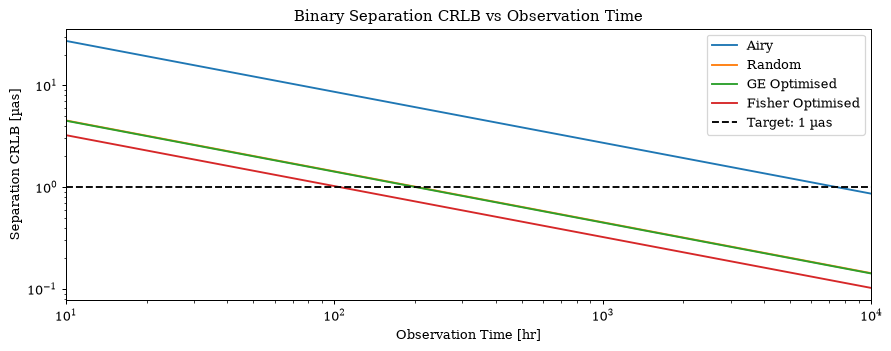

In [ ]:
# Plot the positional constraint as a function of time for each mask
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(hrs, 1e6 * np.array(sep_errs["Airy"]), label="Airy")
ax.plot(hrs, 1e6 * np.array(sep_errs["Random"]), label="Random")
ax.plot(hrs, 1e6 * np.array(sep_errs["GE Optimised"]), label="GE Optimised")
ax.plot(hrs, 1e6 * np.array(sep_errs["Fisher Optimised"]), label="Fisher Optimised")
ax.axhline(1.0, color="k", ls="--", label="Target: 1 µas")
ax.legend()
ax.set(
    title="Binary Separation CRLB vs Observation Time",
    xlabel="Observation Time [hr]",
    ylabel="Separation CRLB [µas]",
    xscale="log",
    yscale="log",
    xlim=(hrs.min(), hrs.max()),
)
plt.tight_layout()
plt.show()

Cool, this is a nice visualisation of how each mask performs compared to one another. Now lets solve for when each of these crosses the 1 micro-arcsecond threshold to get a sense of how much of an improvement we get from our optimisation in terms of the time required to achieve our scientific goal.


In [ ]:
def loglog_crossing(x, y, boundary):
    A = np.stack([np.log(x), np.ones_like(x)], axis=1)
    a, b = np.linalg.lstsq(A, np.log(np.array(y)), rcond=None)[0]
    return np.exp((np.log(boundary) - b) / a)

airy = loglog_crossing(hrs, sep_errs["Airy"], 1e-6)
rand = loglog_crossing(hrs, sep_errs["Random"], 1e-6)
ge = loglog_crossing(hrs, sep_errs["GE Optimised"], 1e-6)
fisher = loglog_crossing(hrs, sep_errs["Fisher Optimised"], 1e-6)

print(f"Fisher optimised mask is {airy / fisher:.1f}x more efficient than the Airy mask")
print(f"Fisher optimised mask is {rand / fisher:.1f}x more efficient than the Random mask")
print(f"Fisher optimised mask is {ge / fisher:.1f}x more efficient than the GE Optimised mask")

Fisher optimised mask is 71.0x more efficient than the Airy mask
Fisher optimised mask is 1.9x more efficient than the Random mask
Fisher optimised mask is 1.9x more efficient than the GE Optimised mask


Cool! As we can see we gain almost a 50x improvement in the time required to achieve our desired separation constraint in comparison to the naive best-choice - the Airy disk. We also gain significant factors of improvement compared to our gradient energy optimised mask, which is a nice demonstration of the power of using a rigorous metric that is directly related to our scientific goal, rather than relying on a heuristic metric that may not be directly related to our scientific goal. This is the power of this design method, it allows us to directly optimise for our scientific goal, while accounting for all of the complexities and covariances in our problem, which is exactly what we want to do in this case.
